# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.proteingym as pg 

## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [2]:
proteins_df = pg.merge_resources()
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:02<00:00,  1.43s/it]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id
0,UPI000000D799,UPI000000D799,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI000000D799
1,UPI0000251DD8,UPI0000251DD8,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000251DD8
2,NP_001001557.1,NP_001001557,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001001557.1
3,NP_060676.2,NP_060676,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060676.2
4,UPI00001AE868,UPI00001AE868,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI00001AE868
...,...,...,...,...,...
4075,NP_055112.2,NP_055112,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_055112.2
4076,NP_004874.1,NP_004874,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_004874.1
4077,NP_001119580.2,NP_001119580,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001119580.2
4078,UPI0000132184,UPI0000132184,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000132184


In [3]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins

,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225
4,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000376802,NP_000286
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000155840,NP_000209


Filter the ProteinGym mutations according to which ones are present in the candidate proteins.

In [4]:
candidate_proteins, prot_map = gp.map_and_filter(candidate_proteins, 
                                                      proteins_df, 
                                                      input_col1="RefSeq Protein", 
                                                      input_col2="protein", 
                                                      target_namespace="ENST", 
                                                      rows_per_id=(1,1))

Mapping df1 IDs to: ENST
Running gprofiler.convert with 11 queries.
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_65e6f498ac1454a23db1aa20e143fa34.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENST
Mapping df2 IDs to: ENST
Running gprofiler.convert with 3548 queries.
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_9531653d2a5824ed015952a216d15023.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENST
df1: Keeping only the first 1 row(s) per ID.
df2: Keeping only the first 1 row(s) per ID.


In [5]:
candidate_proteins

,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable,ENST,HGNC
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENST00000369620,G6PD
24,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401,ENST00000309234,HFE
48,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483,ENST00000003084,CFTR
86,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225,ENST00000352993,BRCA1
127,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050,ENST00000380152,BRCA2
146,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121,ENST00000367796,F5
149,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509,ENST00000335295,HBB
155,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000376802,NP_000286,ENST00000355814,SERPINA1
175,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518,ENST00000252444,LDLR
190,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000155840,NP_000209,ENST00000155840,KCNQ1


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [6]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(tx_ids=prot_map["ENST"].unique(), 
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Getting haplotypes:   0%|          | 0/11 [00:00<?, ?it/s]

Extract just the sequences from the haplotypes dictionary (includes lots of other data/metadata)

In [7]:
hap_seqs = hs.get_haplotype_seqs(haplotypes, 
                                 aligned=2, 
#                                  use_protein_ids=True,
                                 add_haplotype_names=True)

Getting haplotype sequences:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data.

In [8]:
prot_df = vp.filter_prot_df(prot_map, 
                             haplotypes=haplotypes, 
                            run_mapping=False,
                             source_types=["clinical_ProteinGym_substitutions"],
                             verbose=True)
prot_df

ENST_haplosaurus == ENST: 1.0
Filtering by source types: clinical_ProteinGym_substitutions
7 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENST,HGNC,ENST_haplosaurus,ENSP_haplosaurus
427,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENST00000309234,HFE,ENST00000309234,ENSP00000311698
3926,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENST00000252444,LDLR,ENST00000252444,ENSP00000252444
10018,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENST00000003084,CFTR,ENST00000003084,ENSP00000003084
19024,NP_000209.2,NP_000209,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000209.2,ENST00000155840,KCNQ1,ENST00000155840,ENSP00000155840
22014,NP_000286.3,NP_000286,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,ENST00000355814,SERPINA1,ENST00000355814,ENSP00000348068
27717,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENST00000262186,KCNH2,ENST00000262186,ENSP00000262186
33102,NP_000393.4,NP_000393,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000393.4,ENST00000369620,G6PD,ENST00000369620,ENSP00000358633


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [9]:
vp.list_models()

['esm',
 'esm1_t12_85M_UR50S',
 'esm1_t34_670M_UR100',
 'esm1_t34_670M_UR50D',
 'esm1_t34_670M_UR50S',
 'esm1_t6_43M_UR50S',
 'esm1b_t33_650M_UR50S',
 'esm1v_t33_650M_UR90S',
 'esm1v_t33_650M_UR90S_1',
 'esm1v_t33_650M_UR90S_2',
 'esm1v_t33_650M_UR90S_3',
 'esm1v_t33_650M_UR90S_4',
 'esm1v_t33_650M_UR90S_5',
 'esm2_t12_35M_UR50D',
 'esm2_t30_150M_UR50D',
 'esm2_t33_650M_UR50D',
 'esm2_t36_3B_UR50D',
 'esm2_t48_15B_UR50D',
 'esm2_t6_8M_UR50D',
 'esm_if1_gvp4_t16_142M_UR50',
 'esm_msa1_t12_100M_UR50S',
 'esm_msa1b_t12_100M_UR50S',
 'esmfold_v0',
 'esmfold_v1']

Run VEP pipeline and store the results in `save_dir`.

In [2]:
save_dir = os.path.join(config.DATA_DIR,"1KG","vep")

In [ ]:
save_paths = vp.vep_pipeline(
    prot_df = prot_df,
    haplotypes = haplotypes,
    models = ["esm1v_t33_650M_UR90S_1"],
    scoring_strategies = {"esm1v_t33_650M_UR90S_1":[
        "wt-marginals", 
        "masked-marginals",
        # "pseudo-ppl" # Takes much longer to run
        ]},
    run_filter_prot_df=False,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
    )
save_paths

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

In [3]:
vep_df = ESM.merge_vep(save_dir, 
                       add_metadata=True)
vep_df

Found 251 wt-marginals files


Reading files: 100%|██████████| 251/251 [00:01<00:00, 195.60it/s]


Found 250 masked-marginals files


Reading files: 100%|██████████| 250/250 [00:01<00:00, 218.22it/s]


Found 204 pseudo-ppl files


Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 16.33it/s]
/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3301: DtypeWarning: Columns (0,47) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,esm1v_t33_650M_UR90S_1,scoring_strategy,is_ref,model_location,...,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
2,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.943518,-0.011925,7,likely_path
3,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA16602290,NaN,NaN,NaN,NaN,NaN,-0.349066,-0.000457,7,likely_benign
4,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA023728|LDLR-LOVD,_British_Heart_Foun...",NaN,NaN,NaN,NaN,NaN,-0.693519,-0.002438,7,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45502,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,K9E,MVHLTPEEESAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Pathogenic,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA125050|OMIM:141900.0191|UniProtKB:P6...,NaN,NaN,NaN,-5.209094,-4.076734,-4.650674,-0.059732,9,path
45503,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,E8G,MVHLTPEGKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Benign,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA124863|HBVAR:230|OMIM:141900.0086|Un...,NaN,NaN,NaN,-5.896679,-5.485862,-6.678444,-0.111628,9,likely_benign
45504,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,E7V,MVHLTPVEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Pathogenic,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA125138|Genetic_Testing_Registry_(GTR...,.|.|.|.|.|.|MedGen:C1264000,HEMOGLOBIN_JAMAICA_PLAIN|HEMOGLOBIN_S_(ANTILLE...,446730:other|446731:other|446735:Pathogenic|44...,-4.408691,-2.442653,-3.244972,-0.056076,9,path
45505,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,P6A,MVHLTAEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Benign,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,NaN,NaN,NaN,NaN,1.358990,1.112418,0.719250,0.019736,9,likely_benign


In [56]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]
vep_df = hs.add_haplotype_freqs(df= vep_df, 
                                haplotypes = haplotypes, 
                                haplotype_col = "haplotype")
vep_df.head() 

Getting haplotype frequencies:   0%|          | 0/155 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies:   0%|          | 0/32 [00:00<?, ?it/s]

{'GBR': 'EUR', 'FIN': 'EUR', 'CHS': 'EAS', 'PUR': 'AMR', 'CDX': 'EAS', 'CLM': 'AMR', 'IBS': 'EUR', 'PEL': 'AMR', 'PJL': 'SAS', 'KHV': 'EAS', 'ACB': 'AFR', 'GWD': 'AFR', 'ESN': 'AFR', 'BEB': 'SAS', 'MSL': 'AFR', 'STU': 'SAS', 'ITU': 'SAS', 'CEU': 'EUR', 'YRI': 'AFR', 'CHB': 'EAS', 'JPT': 'EAS', 'LWK': 'AFR', 'ASW': 'AFR', 'MXL': 'AMR', 'TSI': 'EUR', 'GIH': 'SAS'}


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,esm1v_t33_650M_UR90S_1,scoring_strategy,is_ref,model_location,variant_set,ENSP_haplosaurus,ENST,HGNC,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_sequence_length,mutated_sequence_length,ENST_haplosaurus,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:CEU,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:IBS,freq_1000GENOMES:phase_3:ITU,freq_1000GENOMES:phase_3:JPT,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop
0,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,ENSP00000252444,ENST00000252444,LDLR,False,19,11089576,250975,T,A,.,PASS,250975,19:11089576,A,3949,NM_000527.5,Transcript,missense_variant,114,28,10,W/R,Tgg/Agg,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.28T>A,NP_000518.1:p.Trp10Arg,-,NaN,NaN,245340,"MONDO:MONDO:0007750,MedGen:C0745103,OMIM:14389...","Hypercholesterolemia,_familial,_1",NC_000019.10:g.11089576T>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254386.0,NaN,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path,860,860,ENST00000252444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N/A
1,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,ENSP00000252444,ENST00000252444,LDLR,False,19,11089592,250981,T,C,.,PASS,250981,19:11089592,C,3949,NM_000527.5,Transcript,missense_variant,130,44,15,L/P,cTc/cCc,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.44T>C,NP_000518.1:p.Leu15Pro,-,NaN,NaN,245347,"MONDO:MONDO:0005439,MedGen:C0020445,OMIM:PS143...",Familial_hypercholesterolemia|not_provided|Hyp...,NC_000019.10:g.11089592T>C,reviewed_by_expert_panel,Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254390.0,NaN,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path,860,860,ENST00000252444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N/A
2,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MG

In [4]:
seq_check_df, clinsig_counts, mutant_in_haplotype = ESM.report_vep(vep_df)
display(seq_check_df, clinsig_counts, mutant_in_haplotype)

,clinsig,mismatched_length,identical_sequences
0,benign,0,0
1,likely_benign,0,0
2,likely_path,0,0
3,path,0,0


,clinsig_count
likely_path,34505
likely_benign,5190
path,4418
benign,1394


,mutant_in_haplotype,clinsig,variant_count,variant_count_by_clinsig,variant_proportion,haplotype_count,haplotype_count_by_clinsig,haplotype_proportion
0,False,benign,11,19,0.578947,214,269,0.795539
1,False,likely_benign,74,81,0.913580,251,258,0.972868
2,False,likely_path,558,558,1.000000,232,232,1.000000
3,False,path,80,83,0.963855,64,68,0.941176
4,True,benign,8,19,0.421053,55,269,0.204461
5,True,likely_benign,7,81,0.086420,7,258,0.027132
6,True,path,3,83,0.036145,4,68,0.058824


Removed 16362 rows with NA values in esm1v_t33_650M_UR90S_1


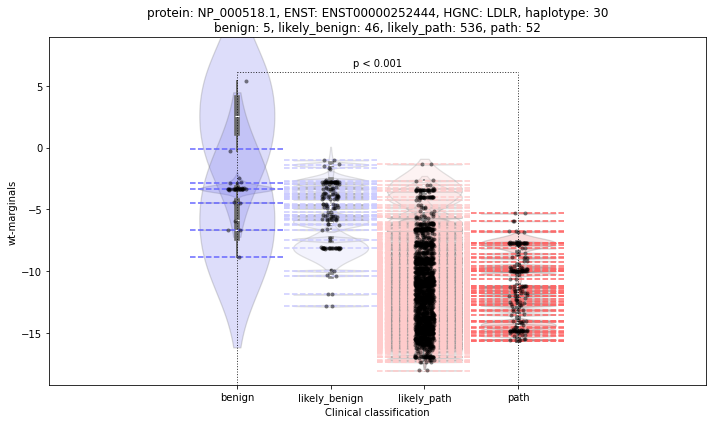

In [17]:
ESM.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    scoring_strategy="wt-marginals",
                    model_location="esm1v_t33_650M_UR90S_1")

Removed 15756 rows with NA values in esm1v_t33_650M_UR90S_1


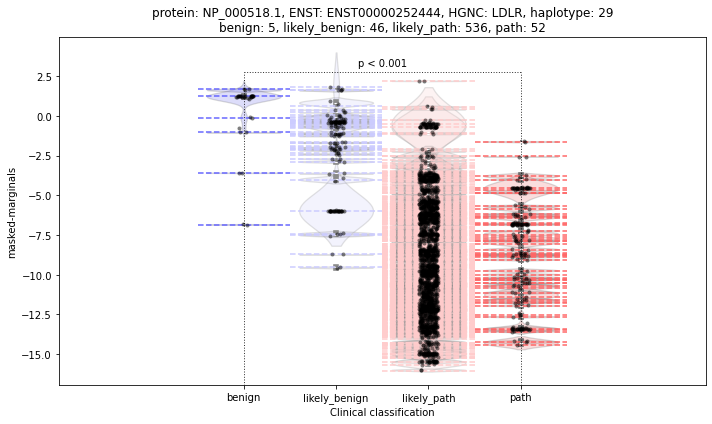

In [18]:
ESM.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    scoring_strategy="masked-marginals",
                    model_location="esm1v_t33_650M_UR90S_1")

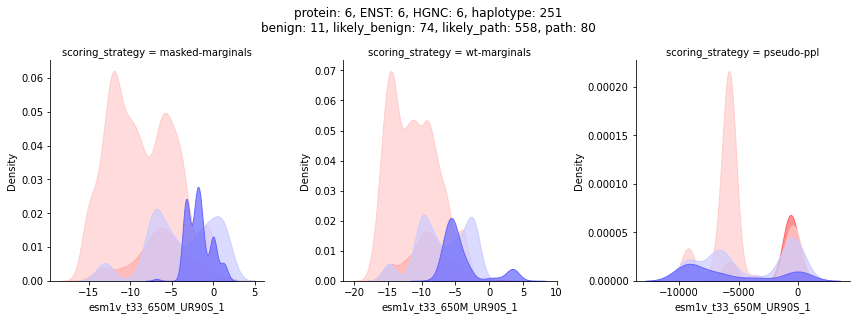

In [24]:
ESM.plot_vep_density(vep_df, multiple='layer')